Made to inspect models that have been trained.

Reads the most recent training run from results/training

## Libraries

In [2]:
import os
os.chdir(r"C:\Users\USER\Documents\GitHub\LIFUS-BRICK")

import sys
sys.path.insert(0, r"C:\Users\USER\Documents\GitHub\LIFUS-BRICK")

import csv
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path
from training.dataset import BRICKDataset
from models.brick import BRICK

## Load Data

In [3]:
TRAIN_NUMBER = 33               # <-- change this
RUN_INDEX = TRAIN_NUMBER - 1

# -------------------------------------------------------
# List available runs and pick one
# -------------------------------------------------------
results_root = Path("results/training")
csv_files = sorted(results_root.glob("*/loss_history.csv"))

if not csv_files:
    raise FileNotFoundError("No loss_history.csv found. Run training first.")

print("Available runs:")
for i, f in enumerate(csv_files):
    print(f"  [{i}] {f.parent.name}")


csv_path = csv_files[RUN_INDEX]
print(f"\nPlotting: {csv_path.parent.name}")
 
# -------------------------------------------------------
# Load CSV
# -------------------------------------------------------
epochs       = []
train_total  = []; val_total   = []
train_recon  = []; val_recon   = []
train_kl_g0  = []; val_kl_g0  = []
train_kl_u   = []; val_kl_u   = []
train_cls    = []; val_cls     = []
 
with open(csv_path) as f:
    for row in csv.DictReader(f):
        epochs.append(int(row["epoch"]))
        train_total.append(float(row["train_loss_total"]))
        val_total.append(float(row["val_loss_total"]))
        train_recon.append(float(row["train_loss_recon"]))
        val_recon.append(float(row["val_loss_recon"]))
        train_kl_g0.append(float(row["train_loss_kl_g0"]))
        val_kl_g0.append(float(row["val_loss_kl_g0"]))
        train_kl_u.append(float(row["train_loss_kl_u"]))
        val_kl_u.append(float(row["val_loss_kl_u"]))
        train_cls.append(float(row["train_loss_cls"]))
        val_cls.append(float(row["val_loss_cls"]))

Available runs:
  [0] train_20260618_143928
  [1] train_20260618_144852
  [2] train_20260619_125015
  [3] train_20260619_134312
  [4] train_20260619_150129
  [5] train_20260622_094554
  [6] train_20260622_140945
  [7] train_20260622_144244
  [8] train_20260622_145154
  [9] train_20260622_160853
  [10] train_20260622_161907
  [11] train_20260623_092253
  [12] train_20260623_093759
  [13] train_20260623_094912
  [14] train_20260623_095954
  [15] train_20260623_101131
  [16] train_20260623_102656
  [17] train_20260623_104108
  [18] train_20260623_104941
  [19] train_20260623_114247
  [20] train_20260623_131014
  [21] train_20260623_132944
  [22] train_20260623_134241
  [23] train_20260623_134655
  [24] train_20260623_135251
  [25] train_20260623_141354
  [26] train_20260623_142622
  [27] train_20260623_154554
  [28] train_20260623_155811
  [29] train_20260623_160725
  [30] train_20260623_161803
  [31] train_20260623_162620
  [32] train_20260624_150557

Plotting: train_20260624_150557


## Plot

Saved to results\figures\training_curves_train_20260624_150557.png


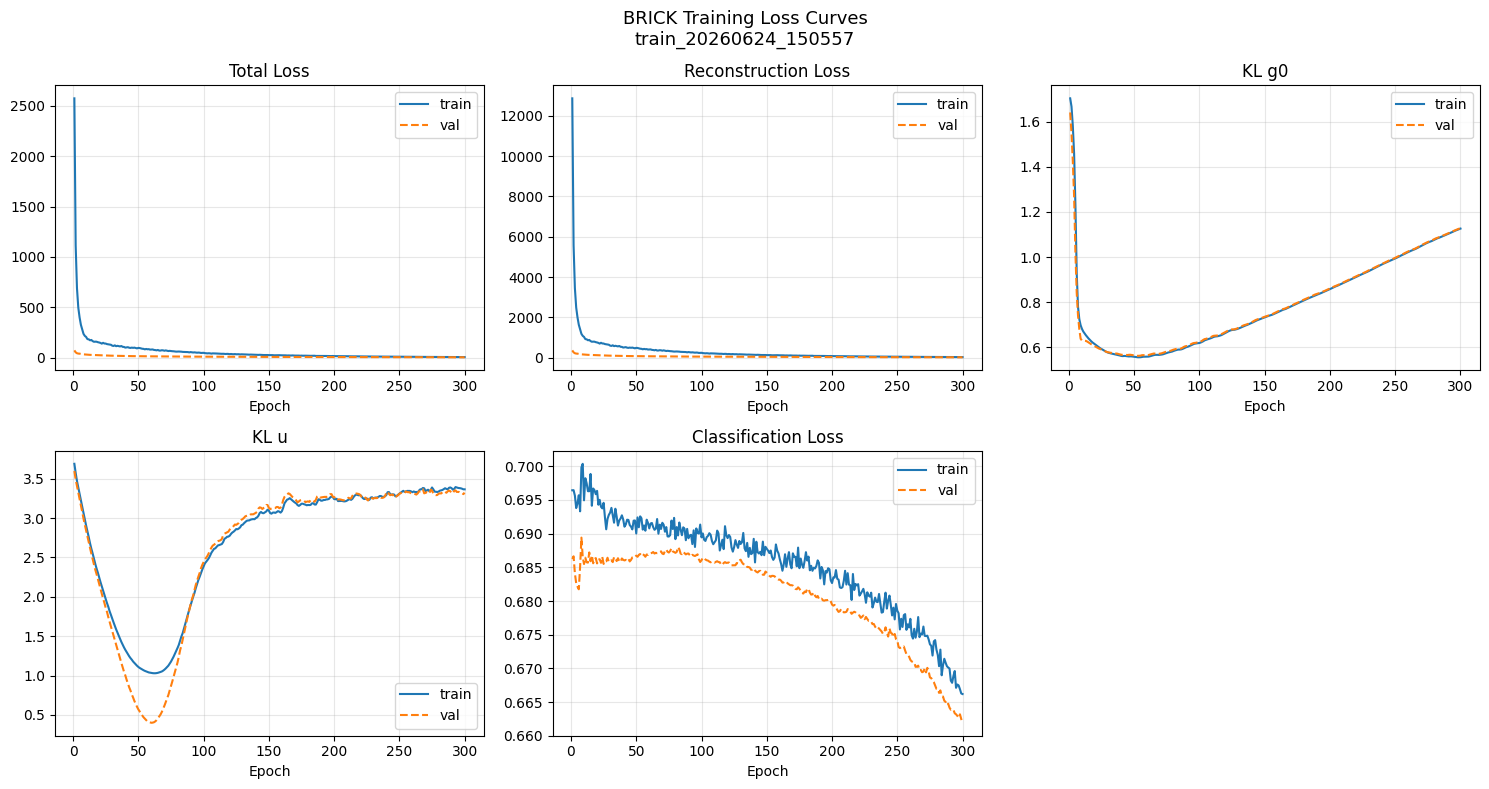

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"BRICK Training Loss Curves\n{csv_path.parent.name}", fontsize=13)
 
def plot(ax, title, train, val=None):
    ax.plot(epochs, train, label="train", linewidth=1.5)
    if val is not None:
        ax.plot(epochs, val, label="val", linewidth=1.5, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
 
plot(axes[0, 0], "Total Loss",            train_total,  val_total)
plot(axes[0, 1], "Reconstruction Loss",   train_recon,  val_recon)
plot(axes[0, 2], "KL g0",                 train_kl_g0,  val_kl_g0)
plot(axes[1, 0], "KL u",                  train_kl_u,   val_kl_u)
plot(axes[1, 1], "Classification Loss",   train_cls,    val_cls)
axes[1, 2].axis("off")
 
plt.tight_layout()
 
# Save
out_path = Path(f"results/figures/training_curves_{csv_path.parent.name}.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()

One concrete check before you change anything: confirm the recon floor in pic 2 actually equals the data variance. If z-scored BOLD has per-feature variance 1 and recon plateaus at ~1.0, that's quantitative confirmation the decoder is predicting the mean and the latent is doing nothing. If it plateaus meaningfully below 1, the latent is still carrying some information and the collapse is partial. That single number tells you how total the collapse is.

In [20]:
import torch
import numpy as np
from pathlib import Path
from training.dataset import BRICKDataset
from models.brick import BRICK

# Load latest checkpoint
runs = sorted(Path("results/training").glob("*/best_model.pt"))
for i, r in enumerate(runs):
    print(f"[{i}] {r.parent.name}")

RUN_INDEX = -1  # most recent
checkpoint = torch.load(runs[RUN_INDEX], map_location="cpu")
model = BRICK(h=checkpoint["h"])
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

ds = BRICKDataset(Path("data/preprocessed_data"))

recon_losses = []
with torch.no_grad():
    for i in range(len(ds)):
        item = ds[i]
        out  = model(item["x"], item["lifus_condition"])
        recon_losses.append(out["losses"]["loss_recon"].item())

mean_recon    = np.mean(recon_losses)
mean_variance = 1.0  # z-scored data always has variance 1

print(f"\nActual recon loss:   {mean_recon:.4f}")
print(f"Recon floor (mean):  {mean_variance:.4f}")
print(f"Ratio recon/floor:   {mean_recon/mean_variance:.4f}")

if mean_recon / mean_variance > 0.95:
    print("-> At the floor. Decoder predicting mean.")
elif mean_recon / mean_variance > 0.50:
    print("-> Partially below floor. Latent carrying some information.")
else:
    print("-> Well below floor. Latent carrying significant information.")

[0] train_20260618_143928
[1] train_20260618_144852
[2] train_20260619_125015
[3] train_20260619_134312
[4] train_20260619_150129
[5] train_20260622_094554
[6] train_20260622_140945

Actual recon loss:   0.0391
Recon floor (mean):  1.0000
Ratio recon/floor:   0.0391
-> Well below floor. Latent carrying significant information.


### Test for VAE posterior collapse vs code bug (grdients not flowing properly)

In [7]:
import torch
from training.dataset import BRICKDataset
from models.brick import BRICK
from pathlib import Path

ds = BRICKDataset(Path("data/preprocessed_data"))

checkpoint = torch.load("results/training/train_20260619_134312/best_model.pt", map_location="cpu")
model = BRICK(use_control=True, use_ic=True, h=2, nhead=2)
model.load_state_dict(checkpoint["model_state_dict"])
model.train()

x     = ds[0]["x"]
label = ds[0]["lifus_condition"]
out   = model(x, label)
out["losses"]["loss_total"].backward()

print("Encoder gradients:")
for name, param in model.encoder.named_parameters():
    if param.grad is not None:
        print(f"  {name}: grad_norm={param.grad.norm().item():.6f}")
    else:
        print(f"  {name}: NO GRADIENT")

Encoder gradients:
  row_mlp.0.weight: grad_norm=0.000000
  row_mlp.0.bias: grad_norm=0.000000
  row_mlp.2.weight: grad_norm=0.000000
  row_mlp.2.bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.in_proj_bias: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.weight: grad_norm=0.000000
  mu_head.layers.0.self_attn.out_proj.bias: grad_norm=0.000000
  mu_head.layers.0.linear1.weight: grad_norm=0.000000
  mu_head.layers.0.linear1.bias: grad_norm=0.000000
  mu_head.layers.0.linear2.weight: grad_norm=0.000000
  mu_head.layers.0.linear2.bias: grad_norm=0.000000
  mu_head.layers.0.norm1.weight: grad_norm=0.000000
  mu_head.layers.0.norm1.bias: grad_norm=0.000000
  mu_head.layers.0.norm2.weight: grad_norm=0.000083
  mu_head.layers.0.norm2.bias: grad_norm=0.000083
  mu_head.layers.1.self_attn.in_proj_weight: grad_norm=0.000056
  mu_head.layers.1.self_attn.in_proj_bias: grad_norm=0.000040
  mu_head.layers.1.self_attn.out_

This is vanishing gradients in the early layers — a secondary issue on top of posterior collapse. The first row_mlp and first transformer layer are essentially not learning because gradients diminish as they backpropagate through the network.
This is expected behavior for a collapsed VAE — when mu≈0 and sigma≈1 (prior), the KL gradient is near zero, so very little signal flows back through the encoder. It's a consequence of collapse, not an independent bug.
Conclusion: No code bug. The collapse is genuine VAE behavior caused by the loss landscape. KL annealing is the right fix — it forces reconstruction gradients to flow through the encoder before KL pressure can cause collapse, which would give the early layers a chance to learn.